# ADB 基础操作调试

用于蛋仔派对自动截图脚本探索。前置条件：

1. 安装 [Android Platform Tools](https://developer.android.com/tools/releases/platform-tools)（含 `adb` 命令），或使用 MuMu 自带 adb
2. 模拟器（如 MuMu）或真机已开启 **USB 调试**
3. 终端能执行 `adb devices` 并看到设备为 `device` 状态

**运行顺序：** 依次运行下方「定义函数」的 4 个代码格，再按需运行用例格。


In [2]:
import subprocess
from datetime import datetime
from pathlib import Path
import re

# 若终端里直接敲 adb 报错，用 MuMu 自带 adb
ADB_BIN = r"C:\Program Files\Netease\MuMu\nx_main\adb.exe"

OUTPUT_DIR = Path("screenshots.adb_test")
OUTPUT_DIR.mkdir(exist_ok=True)

# 当前目标设备；多设备时必须指定，否则 adb shell 会报 "more than one device"
DEVICE_SERIAL: str | None = None


def adb(*args: str, timeout: float = 30) -> subprocess.CompletedProcess:
    """执行 adb 子命令。"""
    cmd = [ADB_BIN]
    if DEVICE_SERIAL and args and args[0] not in {"connect", "devices", "kill-server", "start-server", "disconnect"}:
        cmd.extend(["-s", DEVICE_SERIAL])
    cmd.extend(args)
    print(">", " ".join(cmd))
    return subprocess.run(cmd, capture_output=True, timeout=timeout)


def adb_shell(*args: str, timeout: float = 30) -> subprocess.CompletedProcess:
    return adb("shell", *args, timeout=timeout)


def check_device(prefer: str | None = None) -> str:
    """检查已连接设备，设置并返回 DEVICE_SERIAL。"""
    global DEVICE_SERIAL
    result = adb("devices")
    lines = result.stdout.decode().strip().splitlines()[1:]
    devices = [ln.split()[0] for ln in lines if ln.strip() and "device" in ln.split()[1:]]
    if not devices:
        raise RuntimeError("未检测到设备。请确认模拟器已启动且 adb devices 可见。")

    if prefer and prefer in devices:
        DEVICE_SERIAL = prefer
    elif DEVICE_SERIAL and DEVICE_SERIAL in devices:
        pass
    elif len(devices) == 1:
        DEVICE_SERIAL = devices[0]
    else:
        mumu = [d for d in devices if d.startswith("127.0.0.1:")]
        DEVICE_SERIAL = mumu[0] if mumu else devices[0]
        others = [d for d in devices if d != DEVICE_SERIAL]
        print(f"警告：检测到 {len(devices)} 台设备，已选用: {DEVICE_SERIAL}")
        if others:
            print(f"      其余: {', '.join(others)}（可用 set_device('serial') 切换，或 adb disconnect 断开）")

    return DEVICE_SERIAL


def set_device(serial: str) -> str:
    global DEVICE_SERIAL
    DEVICE_SERIAL = serial
    print(f"当前设备: {DEVICE_SERIAL}")
    return DEVICE_SERIAL


def get_screen_size() -> tuple[int, int]:
    if not DEVICE_SERIAL:
        check_device()
    result = adb_shell("wm", "size")
    text = (result.stdout or result.stderr).decode().strip()
    if result.returncode != 0:
        raise RuntimeError(f"wm size 失败: {text}")
    match = re.search(r"(\d+)\s*x\s*(\d+)", text)
    if not match:
        raise RuntimeError(f"无法解析分辨率，原始输出: {text!r}")
    return int(match.group(1)), int(match.group(2))


def adb_connect(host: str = "127.0.0.1", port: int = 7555) -> None:
    global DEVICE_SERIAL
    target = f"{host}:{port}"
    result = adb("connect", target)
    print(result.stdout.decode().strip() or result.stderr.decode().strip())
    DEVICE_SERIAL = target
    print(f"当前设备: {DEVICE_SERIAL}")

adb_connect(port=16384)
device = check_device()
width, height = get_screen_size()
print(f"已连接设备: {device}")
print(f"屏幕分辨率: {width} x {height}")


> C:\Program Files\Netease\MuMu\nx_main\adb.exe connect 127.0.0.1:16384
already connected to 127.0.0.1:16384
当前设备: 127.0.0.1:16384
> C:\Program Files\Netease\MuMu\nx_main\adb.exe devices
> C:\Program Files\Netease\MuMu\nx_main\adb.exe -s 127.0.0.1:16384 shell wm size
已连接设备: 127.0.0.1:16384
屏幕分辨率: 1600 x 2160


In [3]:
from IPython.display import Image, display

import cv2
import numpy as np

# 内存中最近一次 adb 截图（即使 save=False 也会更新，供 load_screenshot 使用）
LAST_SCREENSHOT_BGR: np.ndarray | None = None
LAST_SCREENSHOT_PATH: Path | None = None


def take_screenshot(save: bool = True, show: bool = True) -> Path | None:
    """截取当前屏幕，可选保存到文件并在 notebook 中预览。"""
    global LAST_SCREENSHOT_BGR, LAST_SCREENSHOT_PATH

    result = adb("exec-out", "screencap", "-p", timeout=15)
    if result.returncode != 0:
        raise RuntimeError(result.stderr.decode())

    png_bytes = result.stdout
    if not png_bytes.startswith(b"\x89PNG"):
        raise RuntimeError("截图数据异常，可能设备未就绪")

    img = cv2.imdecode(np.frombuffer(png_bytes, np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        raise RuntimeError("截图解码失败")
    LAST_SCREENSHOT_BGR = img

    out_path = None
    if save:
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        out_path = OUTPUT_DIR / f"screen_{ts}.png"
        out_path.write_bytes(png_bytes)
        LAST_SCREENSHOT_PATH = out_path
        print(f"已保存: {out_path}")

    if show:
        display(Image(data=png_bytes, width=min(width, 600)))

    return out_path


In [4]:
import cv2
import numpy as np
from IPython.display import Image, display

# ROI 调试上下文：show_roi / show_roi_marked 会自动更新，ocr() 无参时读取
_last_img: np.ndarray | None = None
_last_box: tuple[int, int, int, int] | None = None
_last_roi: np.ndarray | None = None

_OCR_ENGINE = None


def _bgr_to_png(bgr: np.ndarray) -> bytes:
    ok, buf = cv2.imencode(".png", bgr)
    if not ok:
        raise RuntimeError("图像编码失败")
    return buf.tobytes()


def load_screenshot(
    path: Path | str | None = None,
    *,
    fresh: bool = False,
    prefer_memory: bool = True,
) -> np.ndarray:
    """加载截图。fresh=True 强制 adb 重截；默认优先内存中 take_screenshot 的结果。"""
    global LAST_SCREENSHOT_BGR

    if fresh:
        take_screenshot(save=True, show=False)
        assert LAST_SCREENSHOT_BGR is not None
        print(f"已加载: freshly captured ({LAST_SCREENSHOT_BGR.shape[1]} x {LAST_SCREENSHOT_BGR.shape[0]})")
        return LAST_SCREENSHOT_BGR.copy()

    if path is not None:
        path = Path(path)
        img = cv2.imdecode(np.frombuffer(path.read_bytes(), np.uint8), cv2.IMREAD_COLOR)
        if img is None:
            raise RuntimeError(f"无法读取: {path}")
        print(f"已加载: {path}  ({img.shape[1]} x {img.shape[0]})")
        return img

    if prefer_memory and LAST_SCREENSHOT_BGR is not None:
        src = LAST_SCREENSHOT_PATH or "内存中最新截图"
        print(f"已加载: {src}  ({LAST_SCREENSHOT_BGR.shape[1]} x {LAST_SCREENSHOT_BGR.shape[0]})")
        return LAST_SCREENSHOT_BGR.copy()

    candidates = sorted(OUTPUT_DIR.glob("screen_*.png"))
    if candidates:
        path = candidates[-1]
        img = cv2.imdecode(np.frombuffer(path.read_bytes(), np.uint8), cv2.IMREAD_COLOR)
        if img is None:
            raise RuntimeError(f"无法读取: {path}")
        print(f"已加载: {path}  ({img.shape[1]} x {img.shape[0]})")
        return img

    return load_screenshot(fresh=True)


def _set_roi_context(img: np.ndarray, box: tuple[int, int, int, int], roi: np.ndarray) -> None:
    global _last_img, _last_box, _last_roi
    _last_img = img
    _last_box = box
    _last_roi = roi


def crop_roi(img: np.ndarray, box: tuple[int, int, int, int]) -> np.ndarray:
    """按 (x1, y1, x2, y2) 裁剪 ROI。"""
    x1, y1, x2, y2 = box
    h, w = img.shape[:2]
    if not (0 <= x1 < x2 <= w and 0 <= y1 < y2 <= h):
        raise ValueError(f"ROI 越界: box={box}, 图像尺寸=({w}, {h})")
    return img[y1:y2, x1:x2].copy()


def show_bgr(bgr: np.ndarray, max_width: int = 400, title: str = "") -> None:
    if title:
        print(title)
    h, w = bgr.shape[:2]
    if w > max_width:
        scale = max_width / w
        bgr = cv2.resize(bgr, (int(w * scale), int(h * scale)))
    display(Image(data=_bgr_to_png(bgr)))


def show_roi(img: np.ndarray, box: tuple[int, int, int, int], title: str = "ROI") -> np.ndarray:
    """裁剪并预览 ROI，同时更新 ocr() 的默认上下文。"""
    roi = crop_roi(img, box)
    _set_roi_context(img, box, roi)
    show_bgr(roi, max_width=320, title=f"{title}  {box}  ->  {roi.shape[1]}x{roi.shape[0]}")
    return roi


def show_roi_marked(
    img: np.ndarray,
    box: tuple[int, int, int, int],
    color: tuple[int, int, int] = (0, 255, 0),
    thickness: int = 2,
) -> np.ndarray:
    """在全图上画框预览，并更新 ocr() 的默认上下文。"""
    roi = crop_roi(img, box)
    _set_roi_context(img, box, roi)
    vis = img.copy()
    x1, y1, x2, y2 = box
    cv2.rectangle(vis, (x1, y1), (x2 - 1, y2 - 1), color, thickness)
    show_bgr(vis, max_width=min(width, 600), title=f"标注 {box}")
    return roi


def debug_rois(
    boxes: list[tuple[int, int, int, int]],
    img: np.ndarray | None = None,
    labels: list[str] | None = None,
    mark_on_full: bool = True,
    run_ocr: bool = False,
) -> list[np.ndarray]:
    """批量预览多个 ROI；run_ocr=True 时逐个打印 OCR 结果。"""
    if img is None:
        img = load_screenshot()
    rois = []
    for i, box in enumerate(boxes):
        label = labels[i] if labels and i < len(labels) else f"#{i}"
        if mark_on_full:
            show_roi_marked(img, box)
        else:
            _set_roi_context(img, box, crop_roi(img, box))
        rois.append(show_roi(img, box, title=label))
        if run_ocr:
            print(f"{label}: {ocr()!r}")
    return rois


def save_roi(roi: np.ndarray, name: str) -> Path:
    out_dir = OUTPUT_DIR / "roi"
    out_dir.mkdir(exist_ok=True)
    path = out_dir / f"{name}.png"
    path.write_bytes(_bgr_to_png(roi))
    print(f"已保存: {path}")
    return path


_OCR_BACKEND: str | None = None


def _get_ocr_engine():
    """优先 RapidOCR，不可用则回退 EasyOCR。"""
    global _OCR_ENGINE, _OCR_BACKEND
    if _OCR_ENGINE is not None:
        return _OCR_ENGINE

    try:
        from rapidocr_onnxruntime import RapidOCR
        _OCR_ENGINE = RapidOCR()
        _OCR_BACKEND = "rapidocr"
        print("OCR backend: rapidocr")
        return _OCR_ENGINE
    except ImportError:
        pass

    try:
        import easyocr
        _OCR_ENGINE = easyocr.Reader(["ch_sim", "en"], gpu=False, verbose=False)
        _OCR_BACKEND = "easyocr"
        print("OCR backend: easyocr")
        return _OCR_ENGINE
    except ImportError as e:
        raise ImportError(
            "未安装 OCR 引擎。请在 notebook 新建一格运行:\n"
            "  %pip install rapidocr-onnxruntime\n"
            "安装后 Restart Kernel，重跑 ROI 定义格。"
        ) from e


def _resolve_ocr_patch(
    source: np.ndarray | None = None,
    box: tuple[int, int, int, int] | None = None,
) -> np.ndarray:
    if source is not None and box is not None:
        patch = crop_roi(source, box)
        _set_roi_context(source, box, patch)
    elif source is not None:
        patch = source
    elif box is not None:
        img = _last_img if _last_img is not None else load_screenshot()
        patch = crop_roi(img, box)
        _set_roi_context(img, box, patch)
    elif _last_roi is not None:
        patch = _last_roi
    elif _last_img is not None and _last_box is not None:
        patch = crop_roi(_last_img, _last_box)
        _set_roi_context(_last_img, _last_box, patch)
    else:
        raise RuntimeError("无 ROI 上下文。先 show_roi(img, box)，或 ocr(img, box=...)")
    return patch


def _run_ocr(patch: np.ndarray) -> list[dict]:
    engine = _get_ocr_engine()
    if _OCR_BACKEND == "easyocr":
        raw = engine.readtext(patch)
        return [{"text": t, "score": float(s), "box": b} for b, t, s in raw]
    result, _ = engine(patch)
    if not result:
        return []
    return [{"text": t, "score": float(s), "box": b} for b, t, s in result]


def ocr(
    source: np.ndarray | None = None,
    box: tuple[int, int, int, int] | None = None,
    *,
    join: str = "",
    verbose: bool = True,
) -> str:
    """通用 OCR：调试 ROI 时随时调用。

    用法:
      ocr()                       # 最近一次 show_roi / show_roi_marked 的 ROI
      ocr(roi)                    # 传入已裁剪的 BGR 小图
      ocr(img, box=(x1,y1,x2,y2)) # 从全图指定区域识别
      ocr(box=(x1,y1,x2,y2))      # 用最近一次截图 + box
    """
    details = _run_ocr(_resolve_ocr_patch(source, box))
    text = join.join(d["text"] for d in details)
    if verbose:
        if details:
            for d in details:
                print(f"OCR: {d['text']!r}  score={d['score']:.3f}")
        else:
            print("OCR: (empty)")
    return text


def ocr_details(
    source: np.ndarray | None = None,
    box: tuple[int, int, int, int] | None = None,
) -> list[dict]:
    """返回 OCR 明细 [{text, score, box}, ...]，参数同 ocr()。"""
    return _run_ocr(_resolve_ocr_patch(source, box))


def ocr_quad_center(quad) -> tuple[float, float]:
    """OCR 四边形 box 的中心点（相对于 ROI 左上角）。"""
    xs = [p[0] for p in quad]
    ys = [p[1] for p in quad]
    return sum(xs) / len(xs), sum(ys) / len(ys)


def ocr_to_screen_xy(
    roi_box: tuple[int, int, int, int],
    quad,
) -> tuple[int, int]:
    """将 ROI 内 OCR box 转为全屏坐标 (x, y)。"""
    x1, y1, _, _ = roi_box
    cx, cy = ocr_quad_center(quad)
    return int(x1 + cx), int(y1 + cy)


def find_text_positions(
    img: np.ndarray,
    roi_box: tuple[int, int, int, int],
    *targets: str,
    exact: bool = False,
) -> dict[str, tuple[int, int]]:
    """在 ROI 中查找目标文字，返回 {文字: (x, y)} 全屏坐标。"""
    positions: dict[str, tuple[int, int]] = {}
    for item in ocr_details(img, box=roi_box):
        text = item["text"].strip()
        matched = None
        for t in targets:
            if (text == t) if exact else (t in text or text in t):
                matched = t
                break
        if matched is None:
            continue
        positions[matched] = ocr_to_screen_xy(roi_box, item["box"])
    return positions

# --- 界面识别（MuMu 下调试）---
# 修改本段后必须重跑本格
SCREEN_DETECT_VERSION = 6

MAIN_SCREEN_FRIEND_TAB_BOX = (1250, 1395, 1310, 1430)   # 底部 tab，主界面可识别「好友」
RANKING_TRANSIT_BOX = (1700, 700, 1900, 770)            # 排行榜中转弹窗标题区
RANKING_SCREEN_BOX = (0, 0, 500, 200)                   # 左上角标题区（排行榜 / 个人信息）
PROFILE_SCREEN_BOX = (0, 0, 500, 200)                   # 个人信息页面标题区
MATCH_SCREEN_RANK_BOX = (100, 1400, 260, 1600)         # 对局截图界面排名 tab 区

SCREEN_MAIN = "游戏主界面"
SCREEN_RANKING_TRANSIT = "排行榜中转界面"
SCREEN_RANKING = "排行榜界面"
SCREEN_PROFILE = "个人信息页面"
SCREEN_MATCH_TEAM_RANK = "对局截图界面-队伍排名版"
SCREEN_MATCH_SOLO_RANK = "对局截图界面-单人排名版"
SCREEN_UNKNOWN = "未知界面"


def _ocr_has(img: np.ndarray, box: tuple[int, int, int, int], keyword: str) -> str:
    return ocr(img, box=box, verbose=False)


def detect_screen(img: np.ndarray | None = None, *, verbose: bool = True) -> str:
    """识别当前界面。

    判定顺序（命中即返回）：
    1. MATCH_SCREEN_RANK_BOX 含「单人排名」 → 对局截图界面-队伍排名版
    2. MATCH_SCREEN_RANK_BOX 含「双人排名」 → 对局截图界面-单人排名版
    3. RANKING_SCREEN_BOX 含「排行榜」 → 排行榜界面
    4. PROFILE_SCREEN_BOX 含「个人信息」 → 个人信息页面
    5. RANKING_TRANSIT_BOX 含「排行榜」 → 排行榜中转界面
    6. MAIN_SCREEN_FRIEND_TAB_BOX 含「好友」 → 游戏主界面
    7. 否则 → 未知界面
    """
    if img is None:
        img = load_screenshot()

    match_rank_text = _ocr_has(img, MATCH_SCREEN_RANK_BOX, "")
    if "单人排名" in match_rank_text:
        name = SCREEN_MATCH_TEAM_RANK
    elif "双人排名" in match_rank_text:
        name = SCREEN_MATCH_SOLO_RANK
    else:
        title_text = _ocr_has(img, RANKING_SCREEN_BOX, "")
        if "排行榜" in title_text:
            name = SCREEN_RANKING
        elif "个人信息" in title_text:
            name = SCREEN_PROFILE
        else:
            ranking_transit_text = _ocr_has(img, RANKING_TRANSIT_BOX, "排行榜")
            if "排行榜" in ranking_transit_text:
                name = SCREEN_RANKING_TRANSIT
            else:
                tab_text = _ocr_has(img, MAIN_SCREEN_FRIEND_TAB_BOX, "好友")
                name = SCREEN_MAIN if "好友" in tab_text else SCREEN_UNKNOWN

    if verbose:
        print(f"界面识别 v{SCREEN_DETECT_VERSION}: {name}")
        print(f"  对局排名 tab OCR={match_rank_text!r}  box={MATCH_SCREEN_RANK_BOX}")
        print(f"  标题区 OCR={_ocr_has(img, RANKING_SCREEN_BOX, '')!r}  box={RANKING_SCREEN_BOX}")
        print(f"  排行榜中转 OCR={_ocr_has(img, RANKING_TRANSIT_BOX, '排行榜')!r}  box={RANKING_TRANSIT_BOX}")
        print(f"  tab区 OCR={_ocr_has(img, MAIN_SCREEN_FRIEND_TAB_BOX, '好友')!r}  box={MAIN_SCREEN_FRIEND_TAB_BOX}")

    return name


def is_main_screen(img: np.ndarray | None = None, *, verbose: bool = False) -> bool:
    return detect_screen(img, verbose=verbose) == SCREEN_MAIN


def is_ranking_transit_screen(img: np.ndarray | None = None, *, verbose: bool = False) -> bool:
    return detect_screen(img, verbose=verbose) == SCREEN_RANKING_TRANSIT


def is_ranking_screen(img: np.ndarray | None = None, *, verbose: bool = False) -> bool:
    return detect_screen(img, verbose=verbose) == SCREEN_RANKING


def is_profile_screen(img: np.ndarray | None = None, *, verbose: bool = False) -> bool:
    return detect_screen(img, verbose=verbose) == SCREEN_PROFILE


def is_match_team_rank_screen(img: np.ndarray | None = None, *, verbose: bool = False) -> bool:
    return detect_screen(img, verbose=verbose) == SCREEN_MATCH_TEAM_RANK


def is_match_solo_rank_screen(img: np.ndarray | None = None, *, verbose: bool = False) -> bool:
    return detect_screen(img, verbose=verbose) == SCREEN_MATCH_SOLO_RANK


# --- 个人信息页派对回顾入口（新版 UI）---
# 旧版点击后权限提示 ROI 已废弃：不再用 PARTY_REVIEW_PERMISSION_BOX / 查阅权限 判断隐藏。
PROFILE_PARTY_REVIEW_ENTRY_BOX = (510, 450, 700, 550)  # 个人信息页「派对回顾」按钮 OCR
PROFILE_PARTY_REVIEW_TAP = (600, 500)                   # 有入口时点击进入派对回顾
PROFILE_PARTY_REVIEW_ENTRY_TEXT = "派对回顾"


def has_profile_party_review_entry(img: np.ndarray | None = None, *, verbose: bool = True) -> bool:
    """个人信息页：ROI 含「派对回顾」表示该玩家公开派对回顾；否则视为隐藏。"""
    if img is None:
        img = load_screenshot()
    text = _ocr_has(img, PROFILE_PARTY_REVIEW_ENTRY_BOX, "")
    visible = PROFILE_PARTY_REVIEW_ENTRY_TEXT in text or "派对回" in text
    if verbose:
        status = "公开（可见派对回顾入口）" if visible else "隐藏（ROI 未识别到派对回顾）"
        print(f"派对回顾入口: {status}")
        print(f"  OCR={text!r}  box={PROFILE_PARTY_REVIEW_ENTRY_BOX}")
    return visible


In [5]:
import time


def tap(x: int, y: int, delay: float = 0.5) -> None:
    """在 (x, y) 处单击。"""
    adb_shell("input", "tap", str(x), str(y))
    print(f"已点击 ({x}, {y})")
    if delay > 0:
        time.sleep(delay)


In [6]:
def swipe(x1: int, y1: int, x2: int, y2: int, duration_ms: int = 300, delay: float = 0.5) -> None:
    adb_shell("input", "swipe", str(x1), str(y1), str(x2), str(y2), str(duration_ms))
    print(f"已滑动 ({x1},{y1}) -> ({x2},{y2}), {duration_ms}ms")
    if delay > 0:
        time.sleep(delay)


def scroll_up(distance_ratio: float = 0.4, duration_ms: int = 400) -> None:
    cx = width // 2
    y_start = int(height * (0.5 + distance_ratio / 2))
    y_end = int(height * (0.5 - distance_ratio / 2))
    swipe(cx, y_start, cx, y_end, duration_ms)


def scroll_down(distance_ratio: float = 0.4, duration_ms: int = 400) -> None:
    cx = width // 2
    y_start = int(height * (0.5 - distance_ratio / 2))
    y_end = int(height * (0.5 + distance_ratio / 2))
    swipe(cx, y_start, cx, y_end, duration_ms)


def scroll_left(distance_ratio: float = 0.4, duration_ms: int = 400) -> None:
    cy = height // 2
    x_start = int(width * (0.5 + distance_ratio / 2))
    x_end = int(width * (0.5 - distance_ratio / 2))
    swipe(x_start, cy, x_end, cy, duration_ms)


def scroll_right(distance_ratio: float = 0.4, duration_ms: int = 400) -> None:
    cy = height // 2
    x_start = int(width * (0.5 - distance_ratio / 2))
    x_end = int(width * (0.5 + distance_ratio / 2))
    swipe(x_start, cy, x_end, cy, duration_ms)


## 用例：连接与设备信息

函数：`adb_connect` · `check_device` · `get_screen_size`

取消注释后运行本格。

In [7]:
adb_connect(port=16384)
print("设备:", check_device())
print("分辨率:", get_screen_size())
set_device("127.0.0.1:16384")  # 多设备时手动指定


> C:\Program Files\Netease\MuMu\nx_main\adb.exe connect 127.0.0.1:16384
already connected to 127.0.0.1:16384
当前设备: 127.0.0.1:16384
> C:\Program Files\Netease\MuMu\nx_main\adb.exe devices
设备: 127.0.0.1:16384
> C:\Program Files\Netease\MuMu\nx_main\adb.exe -s 127.0.0.1:16384 shell wm size
分辨率: (1600, 2160)
当前设备: 127.0.0.1:16384


'127.0.0.1:16384'

## 用例：截图

函数：`take_screenshot`

用于判断当前位于什么界面。

In [ ]:
# take_screenshot()                                # 保存 + notebook 预览（最常用）
# take_screenshot(save=True, show=False)           # 只落盘，适合连续截图
take_screenshot(save=False, show=True)           # 只预览，不写文件

# 批量截图：滚动列表时连续留存
# for i in range(3):
#     take_screenshot(save=True, show=False)
#     scroll_up()
#     time.sleep(0.8)


In [ ]:
# 若 ocr() 报 ModuleNotFoundError，运行本格一次，然后 Restart Kernel 并重跑 ROI 定义格
# %pip install rapidocr-onnxruntime


## 用例：ROI 调试 + OCR


> C:\Program Files\Netease\MuMu\nx_main\adb.exe -s 127.0.0.1:16384 exec-out screencap -p
已加载: 内存中最新截图  (2160 x 1600)
标注 (1250, 1395, 1310, 1430)


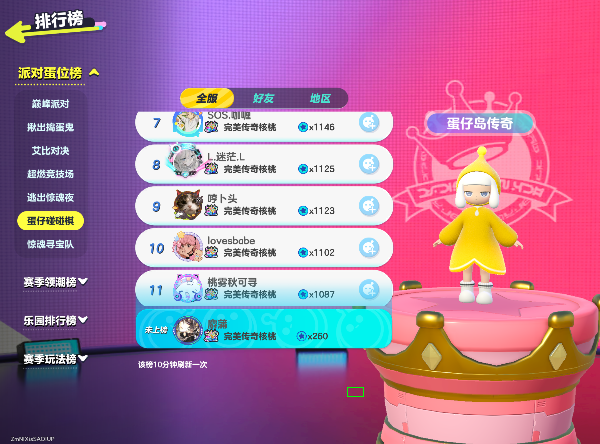

ROI  (1250, 1395, 1310, 1430)  ->  60x35


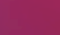

OCR: (empty)


''

In [10]:
# --- ROI 调试 + OCR ---
take_screenshot(save=False, show=False)  
img = load_screenshot()

show_roi_marked(img, MAIN_SCREEN_FRIEND_TAB_BOX)
show_roi(img, MAIN_SCREEN_FRIEND_TAB_BOX)
ocr()

# is_main_screen(img)


In [ ]:
take_screenshot(save=False, show=True)
img = load_screenshot()
detect_screen(img)

if is_match_team_rank_screen(img):
    print("对局截图界面-队伍排名版")
elif is_match_solo_rank_screen(img):
    print("对局截图界面-单人排名版")
elif is_ranking_screen(img):
    print("排行榜界面")
elif is_profile_screen(img):
    print("个人信息页面")
elif is_ranking_transit_screen(img):
    print("排行榜中转界面")
elif is_main_screen(img):
    print("游戏主界面")
else:
    print("未知界面")


In [ ]:
# --- ROI 调试 + OCR（派对回顾）---
take_screenshot(save=False, show=False)
img = load_screenshot()
box = (400, 500, 900, 1100)
show_roi_marked(img, box)
show_roi(img, box)

# --- 派对回顾入口（应在个人信息页判断；列表页仅作参考）---
# 旧 is_party_review_private 已废弃。

# --- 每条 OCR 的全局坐标（含多个「双人巅峰」及时间）---
details = ocr_details(img, box=box)
duo_peak_n = 0
print("--- OCR 全局坐标 ---")
for i, item in enumerate(details):
    x, y = ocr_to_screen_xy(box, item["box"])
    text = item["text"]
    print(f"[{i}] OCR: {text!r}  score={item['score']:.3f}  screen=({x}, {y})")
    if "双人巅峰" in text:
        duo_peak_n += 1
        print(f"      双人巅峰 #{duo_peak_n}  x={x}, y={y}")

if duo_peak_n == 0:
    print("（未识别到含「双人巅峰」的条目）")


In [ ]:
# --- ROI 调试 + OCR（对局截图排名 tab）---
take_screenshot(save=False, show=False)
img = load_screenshot()
box = MATCH_SCREEN_RANK_BOX
show_roi_marked(img, box)
show_roi(img, box)
ocr()

# --- 界面识别 ---
detect_screen(img)
# is_match_team_rank_screen(img)   # 「单人排名」→ 队伍排名版
# is_match_solo_rank_screen(img)   # 「双人排名」→ 单人排名版

> C:\Program Files\Netease\MuMu\nx_main\adb.exe -s 127.0.0.1:16384 exec-out screencap -p
已加载: 内存中最新截图  (2160 x 1600)
标注 (1270, 100, 2050, 300)


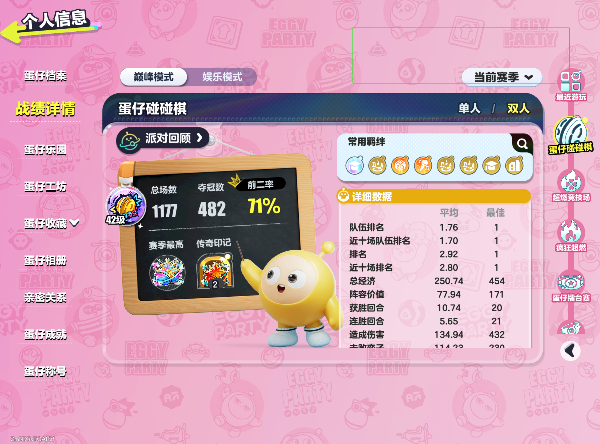

ROI  (1270, 100, 2050, 300)  ->  780x200


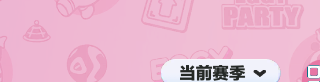

OCR: 'P'  score=0.898
OCR: '当前赛季'  score=0.997
OCR: '口'  score=0.836


'P当前赛季口'

In [15]:
# --- ROI 调试 + OCR（对局截图排名 tab）---
take_screenshot(save=False, show=False)
img = load_screenshot()
box = (1270,100,2050,300)
show_roi_marked(img, box)
show_roi(img, box)
ocr()

# --- 界面识别 ---
# is_match_team_rank_screen(img)   # 「单人排名」→ 队伍排名版
# is_match_solo_rank_screen(img)   # 「双人排名」→ 单人排名版

In [16]:
# tap(2080, 450) # 在主界面点击可弹出进入排行榜的中转弹窗
# tap(1820, 700) # 打开中转界面后，点击可进入排行榜界面
# 排行榜界面中连续点击，可进入碰碰棋排行榜界面
# tap(200, 800) # step1
# tap(750, 350) # step2

# 前三名玩家单独处理
# tap(700, 500)
# tap(700, 640)
# tap(700, 800)

# 每次滚动后对新出现的两位玩家进行操作，首次无需滚动，对应的是第4第5
# tap(700, 933) # 进入第一位玩家的主页
# 点击后若没有进入个人信息页面，还是在排行榜界面，说明该玩家不公开个人信息，跳过。
# tap(600, 500) # 个人信息页 ROI 识别到「派对回顾」后，点击进入派对回顾（旧坐标 200,400 已废弃）
# take_screenshot(save=False, show=False)
# img = load_screenshot()
# if has_profile_party_review_entry(img):  # OCR PROFILE_PARTY_REVIEW_ENTRY_BOX=(510,450,700,550)
#     tap(600, 500)
#     print("公开派对回顾，进入后抓取蛋仔碰碰棋双人巅峰")
# else:
#     print("该玩家隐藏派对回顾，直接返回排行榜")
#     # tap(200, 100)
# 公开玩家进入派对回顾后：直接 OCR 全部记录，识别蛋仔碰碰棋双人巅峰并截图
# tap(1840, 562) # 通过ocr识别出交替的“双人巅峰”和时间字段，用他们纵坐标的平均作为按钮的纵坐标，横坐标为1840，点击可进入对局界面
# tap(200, 1500) # 进入对局界面默认是队伍排名，点击可切换为单人排名
# 在单人排名界面进行截图操作并保存
# tap(1900, 1500)  # 点击可从对局截图界面（单人双人均可）返回派对回顾界面



# tap(200, 100) # 跳过或对局截图逻辑判断结束，点击可从个人信息页面返回排行榜页面


# tap(700, 1080) # 进入第二位玩家的主页
# 操作同上

# 第二位玩家操作结束后，启动新一轮滑动循环。

tap(2050,300)


> C:\Program Files\Netease\MuMu\nx_main\adb.exe -s 127.0.0.1:16384 shell input tap 2050 300
已点击 (2050, 300)


In [ ]:
# swipe(1000, 1000, 1000, 778.35, duration_ms=500)     # 在排行榜界面一次滑动可更新2位玩家
swipe(1000, 1000, 1000, 870, duration_ms=500)     # 在排行榜界面一次滑动可更新1位玩家
# swipe(1000, 1000, 1000, 775, duration_ms=500)     # 在个人信息页面进入派对回顾后，一次滑动可更新两场对局


In [ ]:
# --- ROI 调试 + OCR（个人信息页派对回顾入口）---
take_screenshot(save=False, show=False)
img = load_screenshot()
box = (510,450,700,550)
show_roi_marked(img, box)
show_roi(img, box)
ocr()

In [ ]:
# 个人信息页：仅当 ROI 识别到「派对回顾」时点击该点进入派对回顾
tap(600, 500)


In [ ]:
# 卡牌名称
take_screenshot(save=False, show=False)
img = load_screenshot()
box = (1650,650,2130,780)
show_roi_marked(img, box)
show_roi(img, box)
ocr()

In [ ]:
# 卡牌文字详情
take_screenshot(save=False, show=False)
img = load_screenshot()
box = (1650,780,2130,1120)
show_roi_marked(img, box)
show_roi(img, box)
ocr()

In [ ]:
# 卡牌名称
take_screenshot(save=False, show=False)
img = load_screenshot()
box = (0,0,1360,330)
show_roi_marked(img, box)

In [ ]:
# 点击可以打开第i+1位玩家的第j+1个卡牌
x_offset = [0, 77, 154]
y_offset = [0, 93, 187, 280, 373, 466, 560, 653]
i, j = 0, 0
x, y = 1360 + x_offset[i], 330 + y_offset[j]
tap(x, y)